# Load Data

In [1]:
import pandas as pd
from classify_response import classify_response_factual_recall
import os #SPECIFIC TO ATHU OSCAR
import sys
os.environ["HF_HOME"] = "/oscar/scratch/aparasel/hf_cache"
#os.environ["TRANSFORMERS_CACHE"] = "/oscar/scratch/aparasel/hf_cache/transformers"
#os.environ["DATASETS_CACHE"] = "/oscar/scratch/aparasel/hf_cache/datasets"
os.environ["HF_HUB_CACHE"] = "/oscar/scratch/aparasel/hf_cache/hub"


import torch
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
import re
import json
from tqdm import tqdm
tqdm.pandas()

In [2]:
JUDGE_MODEL_NAME = "meta-llama/Meta-Llama-3-8B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(JUDGE_MODEL_NAME, use_fast=True)
model = AutoModelForCausalLM.from_pretrained(
    JUDGE_MODEL_NAME,
    device_map="auto",
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
)
model.eval()

class Llama3Judge:
    def __init__(self, model, tokenizer):
        self.model = model
        self.tokenizer = tokenizer

    @torch.inference_mode()
    def generate(self, prompt: str, temperature: float = 0.0, max_tokens: int = 5) -> str:
        # Llama 3 Instruct uses chat template
        messages = [{"role": "user", "content": prompt}]
        if hasattr(self.tokenizer, "apply_chat_template"):
            text = self.tokenizer.apply_chat_template(
                messages, tokenize=False, add_generation_prompt=True
            )
        else:
            text = prompt

        inputs = self.tokenizer(text, return_tensors="pt", padding=False).to(self.model.device)

        do_sample = (temperature is not None) and (temperature > 0.0)
        out = self.model.generate(
            **inputs,
            max_new_tokens=max_tokens,
            do_sample=do_sample,
            temperature=temperature if do_sample else None,
            top_p=0.95 if do_sample else None,
            pad_token_id=self.tokenizer.eos_token_id,
            eos_token_id=self.tokenizer.eos_token_id,
        )

        prompt_len = inputs["input_ids"].shape[1]
        gen_tokens = out[0, prompt_len:]
        return self.tokenizer.decode(gen_tokens, skip_special_tokens=True)

judge_model = Llama3Judge(model, tokenizer)
#judge_model = None

In [3]:
MAPPING = {"Temporal_error": "What year was the entity born?", "location_error":"What is the nationality of the entity?", "Career_error":"What is the occupation of the entity?"}
def load_forwardpatch_df(base="/users/aparasel/scratch/VvsLMem-Cntxt-Conflict/Scripts/FRQ/Corruption_Results/FRQ_frontpatch_freeze_qwen_celeb_vision_split",classify=False,num_layers=20):
    dfs_vis = []
    for i in range(num_layers):
        df_temp = pd.read_csv(f"{base}{i}.csv")
        if classify:
            df_temp["Pred"] = df_temp.progress_apply(
                        lambda x: classify_response_factual_recall(
                            query=MAPPING[x["Category"]],
                            parametric_ans=x["Parametric_ans"],
                            response=x['New_Answer'],
                            judge_model=judge_model,
                        ),
                        axis=1,
                    )
            df_temp.to_csv(f"{base}{i}.csv")
        df_temp = df_temp.drop_duplicates(['Entity', 'Category'])
        dfs_vis.append(df_temp)
    df_all = pd.concat(dfs_vis, ignore_index=True)
    return df_all


In [4]:
df_qwen_vis = load_forwardpatch_df(base="/users/aparasel/scratch/VvsLMem-Cntxt-Conflict/Scripts/FRQ/Corruption_Results/FRQ_frontpatch_freeze_qwen_celeb_vision_split",classify=True)
df_qwen_vis.head(3)

,Unnamed: 0,ID,Entity,Category,Group,Original_output,Original_top_token,Mis_Knowledge_Key,Parametric_ans,src_start,dst_start,num_layers,New_Answer,TopDecodedTokenID,TopDecodedToken,Pred
0,0,1,Taylor Swift,Temporal_error,VisTxtCont,1988.,1,mis_knowledge1,1989,0,0,1,1989,16,1,CORRECT
1,2,1,Taylor Swift,location_error,VisTxtCont,Canadian.,Canadian,mis_knowledge1,American,0,0,1,American.,28418,American,CORRECT
2,4,1,Taylor Swift,Career_error,VisTxtCont,Novelist.,Nov,mis_knowledge1,singer-songwriter,0,0,1,Singer-songwriter.,50,S,CORRECT


In [5]:
df_qwen_text = load_forwardpatch_df(base="/users/aparasel/scratch/VvsLMem-Cntxt-Conflict/Scripts/FRQ/Corruption_Results/FRQ_frontpatch_freeze_qwen_celeb_text_split",classify=False)
df_qwen_text.head(3)

,Unnamed: 0,ID,Entity,Category,Group,Original_output,Original_top_token,Mis_Knowledge_Key,Parametric_ans,src_start,dst_start,num_layers,New_Answer,TopDecodedTokenID,TopDecodedToken,Pred
0,0,1,Taylor Swift,Temporal_error,VisTxtCont,1988.,1,mis_knowledge1,1989,0,0,1,1989,16,1,CORRECT
1,2,1,Taylor Swift,location_error,VisTxtCont,Canadian.,Canadian,mis_knowledge1,American,0,0,1,American.,28418,American,CORRECT
2,4,1,Taylor Swift,Career_error,VisTxtCont,Novelist.,Nov,mis_knowledge1,singer-songwriter,0,0,1,Singer-songwriter.,50,S,CORRECT


In [6]:
df_gemma_vision = load_forwardpatch_df(base="/users/aparasel/scratch/VvsLMem-Cntxt-Conflict/Scripts/FRQ/Corruption_Results/FRQ_frontpatch_freeze_gemma_celeb_vision_split",classify=False)
df_gemma_vision.head(3)

,Unnamed: 0,ID,Entity,Category,Group,Original_output,Original_top_token,Mis_Knowledge_Key,Parametric_ans,src_start,dst_start,num_layers,New_Answer,TopDecodedTokenID,TopDecodedToken,Pred
0,0,1,Taylor Swift,Temporal_error,VisTxtCont,1988,1,mis_knowledge1,1989,0,0,1,1989,236770,1,CORRECT
1,2,1,Taylor Swift,location_error,VisTxtCont,Canadian,Canadian,mis_knowledge1,American,0,0,1,American.,14645,American,CORRECT
2,4,1,Taylor Swift,Career_error,VisTxtCont,Novelist.,Nov,mis_knowledge1,singer-songwriter,0,0,1,Singer-songwriter,119783,Singer,CORRECT


In [7]:
df_gemma_text = load_forwardpatch_df(base="/users/aparasel/scratch/VvsLMem-Cntxt-Conflict/Scripts/FRQ/Corruption_Results/FRQ_frontpatch_freeze_gemma_celeb_text_split",classify=False)
df_gemma_text.head(3)

,Unnamed: 0,ID,Entity,Category,Group,Original_output,Original_top_token,Mis_Knowledge_Key,Parametric_ans,src_start,dst_start,num_layers,New_Answer,TopDecodedTokenID,TopDecodedToken,Pred
0,0,1,Taylor Swift,Temporal_error,VisTxtCont,1988,1,mis_knowledge1,1989,0,0,1,1989,236770,1,CORRECT
1,2,1,Taylor Swift,location_error,VisTxtCont,Canadian,Canadian,mis_knowledge1,American,0,0,1,American.,14645,American,CORRECT
2,4,1,Taylor Swift,Career_error,VisTxtCont,Novelist.,Nov,mis_knowledge1,singer-songwriter,0,0,1,Singer-songwriter,119783,Singer,CORRECT


In [8]:
dfs = [df_qwen_vis, df_qwen_text, df_gemma_vision, df_gemma_text]

# Qwen

In [9]:
dfs[0].head(5)

,Unnamed: 0,ID,Entity,Category,Group,Original_output,Original_top_token,Mis_Knowledge_Key,Parametric_ans,src_start,dst_start,num_layers,New_Answer,TopDecodedTokenID,TopDecodedToken,Pred
0,0,1,Taylor Swift,Temporal_error,VisTxtCont,1988.,1,mis_knowledge1,1989,0,0,1,1989,16,1,CORRECT
1,2,1,Taylor Swift,location_error,VisTxtCont,Canadian.,Canadian,mis_knowledge1,American,0,0,1,American.,28418,American,CORRECT
2,4,1,Taylor Swift,Career_error,VisTxtCont,Novelist.,Nov,mis_knowledge1,singer-songwriter,0,0,1,Singer-songwriter.,50,S,CORRECT
3,6,2,Elon Musk,Temporal_error,VisTxtCont,1970.,1,mis_knowledge1,1971,0,0,1,1971,16,1,CORRECT
4,8,2,Elon Musk,Career_error,VisTxtCont,Professional athlete.,Professional,mis_knowledge1,"business magnate, investor, and engineer",0,0,1,Entrepreneur and inventor.,70588,Entre,CORRECT


In [13]:
dfs[0]['Group'].value_counts()

Group
VisTxtCont          3560
VisParam_TxtCont    1460
VisTxtParam          760
VisCont_TxtParam     240
Name: count, dtype: int64

In [22]:
dfs[0].head(10) #Knows parametric at that layer

,Unnamed: 0,ID,Entity,Category,Group,Original_output,Original_top_token,Mis_Knowledge_Key,Parametric_ans,src_start,dst_start,num_layers,New_Answer,TopDecodedTokenID,TopDecodedToken,Pred
0,0,1,Taylor Swift,Temporal_error,VisTxtCont,1988.,1,mis_knowledge1,1989,0,0,1,1989,16,1,CORRECT
1,2,1,Taylor Swift,location_error,VisTxtCont,Canadian.,Canadian,mis_knowledge1,American,0,0,1,American.,28418,American,CORRECT
2,4,1,Taylor Swift,Career_error,VisTxtCont,Novelist.,Nov,mis_knowledge1,singer-songwriter,0,0,1,Singer-songwriter.,50,S,CORRECT
3,6,2,Elon Musk,Temporal_error,VisTxtCont,1970.,1,mis_knowledge1,1971,0,0,1,1971,16,1,CORRECT
4,8,2,Elon Musk,Career_error,VisTxtCont,Professional athlete.,Professional,mis_knowledge1,"business magnate, investor, and engineer",0,0,1,Entrepreneur and inventor.,70588,Entre,CORRECT
5,10,3,Cristiano Ronaldo,Temporal_error,VisTxtCont,1984.,1,mis_knowledge1,1985,0,0,1,1985,16,1,CORRECT
6,12,3,Cristiano Ronaldo,location_error,VisTxtCont,Spanish.,Spanish,mis_knowledge1,Portuguese,0,0,1,Portuguese.,7084,Port,CORRECT
7,14,3,Cristiano Ronaldo,Career_error,VisParam_TxtCont,Professional soccer player.,Professional,mis_knowledge1,professional footballer,0,0,1,Professional footballer.,57513,Professional,CORRECT
8,16,4,Dwayne Johnson,location_error,VisTxtCont,Canadian.,Canadian,mis_knowledge1,American,0,0,1,American.,28418,American,CORRECT
9,18,4,Dwayne Johnson,Career_error,VisCont_TxtParam,"Actor, producer, chef.",Actor,mis_knowledge1,"professional wrestler, actor, and producer",0,0,1,Actor and wrestler.,18870,Actor,CORRECT


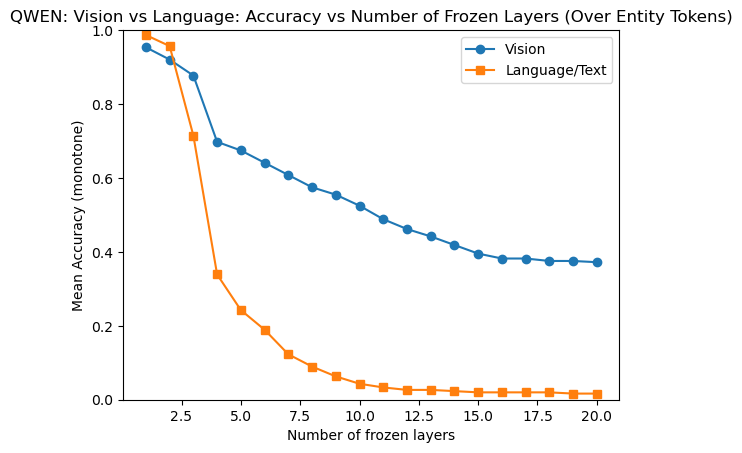

(num_layers
 1     0.953488
 2     0.920266
 3     0.877076
 4     0.697674
 5     0.674419
 6     0.641196
 7     0.607973
 8     0.574751
 9     0.554817
 10    0.524917
 11    0.488372
 12    0.461794
 13    0.441860
 14    0.418605
 15    0.395349
 16    0.382060
 17    0.382060
 18    0.375415
 19    0.375415
 20    0.372093
 Name: Correct, dtype: float64,
 num_layers
 1     0.986711
 2     0.956811
 3     0.714286
 4     0.338870
 5     0.242525
 6     0.189369
 7     0.122924
 8     0.089701
 9     0.063123
 10    0.043189
 11    0.033223
 12    0.026578
 13    0.026578
 14    0.023256
 15    0.019934
 16    0.019934
 17    0.019934
 18    0.019934
 19    0.016611
 20    0.016611
 Name: Correct, dtype: float64)

In [18]:


def load_and_monotone_correct(df, n_layers, Category_type=None) -> pd.Series:


    df_all = df.copy()
    if Category_type is not None:
        df_all[df_all['Category'] == Category_type]

    # raw correctness
    df_all["Correct_raw"] = (df_all["Pred"] == "CORRECT")

    # one row per (Entity, Category, num_layers)
    df_all = df_all.drop_duplicates(["Entity", "Category", "num_layers"])

    # monotone: once wrong, always wrong for higher num_layers (per Entity, Category)
    df_all = df_all.sort_values(["Entity", "Category", "num_layers"])
    df_all["Correct"] = (
        df_all.groupby(["Entity", "Category"])["Correct_raw"].cummin()
    )

    # accuracy curve
    acc_by_layers = df_all.groupby("num_layers")["Correct"].mean().sort_index()
    return acc_by_layers

# --- compute curves ---
acc_vis = load_and_monotone_correct(dfs[0],20)          # vision
acc_txt = load_and_monotone_correct(dfs[1],20)      # language/text

# --- overlay plot ---
plt.figure()
plt.plot(acc_vis.index, acc_vis.values, marker="o")
plt.plot(acc_txt.index, acc_txt.values, marker="s")
plt.xlabel("Number of frozen layers")
plt.ylabel("Mean Accuracy (monotone)")
plt.title("QWEN: Vision vs Language: Accuracy vs Number of Frozen Layers (Over Entity Tokens)")
plt.legend(["Vision", "Language/Text"])
plt.ylim(0, 1)
plt.show()

acc_vis, acc_txt

# Gemma

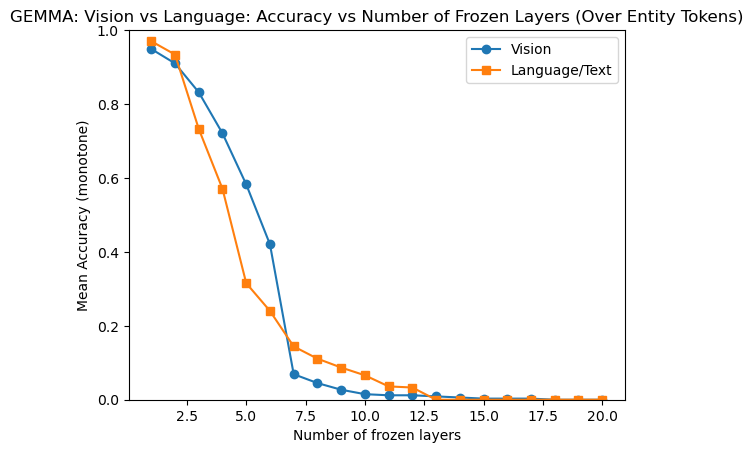

(num_layers
 1     0.948949
 2     0.909910
 3     0.831832
 4     0.720721
 5     0.582583
 6     0.420420
 7     0.069069
 8     0.045045
 9     0.027027
 10    0.015015
 11    0.012012
 12    0.012012
 13    0.009009
 14    0.006006
 15    0.003003
 16    0.003003
 17    0.003003
 18    0.000000
 19    0.000000
 20    0.000000
 Name: Correct, dtype: float64,
 num_layers
 1     0.969970
 2     0.933934
 3     0.732733
 4     0.570571
 5     0.315315
 6     0.240240
 7     0.144144
 8     0.111111
 9     0.087087
 10    0.066066
 11    0.036036
 12    0.033033
 13    0.000000
 14    0.000000
 15    0.000000
 16    0.000000
 17    0.000000
 18    0.000000
 19    0.000000
 20    0.000000
 Name: Correct, dtype: float64)

In [21]:


# def load_and_monotone_correct(df, n_layers) -> pd.Series:


#     df_all = df

#     # raw correctness
#     df_all["Correct_raw"] = (df_all["Pred"] == "CORRECT")

#     # one row per (Entity, Category, num_layers)
#     df_all = df_all.drop_duplicates(["Entity", "Category", "num_layers"])

#     # monotone: once wrong, always wrong for higher num_layers (per Entity, Category)
#     df_all = df_all.sort_values(["Entity", "Category", "num_layers"])
#     df_all["Correct"] = (
#         df_all.groupby(["Entity", "Category"])["Correct_raw"].cummin()
#     )

#     # accuracy curve
#     acc_by_layers = df_all.groupby("num_layers")["Correct"].mean().sort_index()
#     return acc_by_layers

# --- compute curves ---
acc_vis = load_and_monotone_correct(dfs[2],20)          # vision
acc_txt = load_and_monotone_correct(dfs[3],20)      # language/text

# --- overlay plot ---
plt.figure()
plt.plot(acc_vis.index, acc_vis.values, marker="o")
plt.plot(acc_txt.index, acc_txt.values, marker="s")
plt.xlabel("Number of frozen layers")
plt.ylabel("Mean Accuracy (monotone)")
plt.title("GEMMA: Vision vs Language: Accuracy vs Number of Frozen Layers (Over Entity Tokens)")
plt.legend(["Vision", "Language/Text"])
plt.ylim(0, 1)
plt.show()

acc_vis, acc_txt

In [12]:
import pandas as pd
df_orig = pd.read_csv("/users/aparasel/scratch/VvsLMem-Cntxt-Conflict/Scripts/FRQ/Corruption_Results/FRQ_frontpatch_freeze_outputs_24_text.csv")
df_orig['New_Answer'].value_counts()

New_Answer
Actor.                             58
Not specified.                     36
Unknown.                           34
Actor/Writer                       27
Actress.                           26
Writer/Author.                     14
Unknown occupation.                10
Politician.                         8
Actress                             4
Actor/Actress.                      4
Singer-songwriter.                  4
Professional basketball player.     4
Actor/Artist.                       4
Actor/Entertainer.                  4
TV host                             2
Professional footballer.            2
Actor/Writer/Producer.              2
Musician and rapper.                2
President                           2
Entrepreneur and CEO.               2
Priest                              2
Card player.                        2
Historian.                          2
Software Engineer.                  2
Athlete.                            2
Professional tennis player.         2
F